# Phase 4B: Subspace Divergence

Find the specific directions in layer 15 residual stream space where NTP and STP
representations diverge, then characterize what those directions encode.

**Method**: `delta = acts_STP - acts_NTP` (per token, same sequences). PCA of
mean-centered delta reveals directions of maximum representational change.
Decode top-projection tokens to characterize each direction.

**Key question**: Is the LoRA-induced change structured (few PCs explain most
variance, specific token types dominate) or diffuse (many PCs, random tokens)?

In [1]:
from phase4b_subspace import (
    load_chat_texts,
    collect_paired_activations,
    divergence_pca,
    characterize_directions,
    get_structural_token_ids,
    print_pc_summary,
    variance_budget,
    plot_scree,
    plot_token_types_per_pc,
    plot_pc1_pc2_scatter,
)
from transformers import AutoTokenizer
import numpy as np

MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
LAYER = 15
SEQ_LEN = 128
BATCH_SIZE = 8
TOP_K_PCS = 32

## Load Data

In [2]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
tokenizer.pad_token = tokenizer.eos_token

synth_texts, _ = load_chat_texts("../datasets/synth_test.jsonl", tokenizer)
print(f"Synth test: {len(synth_texts)} examples")

Synth test: 2000 examples


## Step 1: Collect Paired Activations

Both models see the exact same token sequences. We tokenize once and feed the
same batches to each model. This ensures delta[i] is meaningful.

In [3]:
print("Collecting paired activations at layer", LAYER)
acts_ntp, acts_stp, token_ids, seq_indices = collect_paired_activations(
    MODELS["NTP"], MODELS["STP"],
    synth_texts,
    layer=LAYER,
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
)
print(f"\nDone. acts shape: {tuple(acts_ntp.shape)}")

  Tokenized: 142,247 real tokens from 2000 sequences
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  acts_a: (142247, 2048), dtype=torch.float32
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  acts_b: (142247, 2048), dtype=torch.float32

Done. acts shape: (142247, 2048)


## Step 2: Delta PCA

Compute delta = STP - NTP, mean-center it (removes global shift), then SVD
to find principal components of the divergence.

Mean-centering is important: without it, PC1 would just be the average direction
STP shifted all tokens — trivial. After centering, PCs capture token-specific
patterns of divergence.

In [4]:
print("Running divergence PCA...")
components, eigenvalues, cumvar, projections, mean_shift, delta_norm_ratio = divergence_pca(
    acts_ntp, acts_stp, top_k=TOP_K_PCS
)

Running divergence PCA...
  delta shape: (142247, 2048)
  ||delta||_F / ||acts_a||_F = 0.3802 (38.02%)
  mean shift norm: 1.4394
  Running truncated SVD (top_k=32)...
  Top eigenvalue fraction: 0.558
  Components to reach 50% var: 1
  Components to reach 80% var: 19
  Components to reach 90% var: 33


## Step 3: Variance Budget

In [5]:
variance_budget(acts_ntp, acts_stp, eigenvalues, cumvar, delta_norm_ratio)


Variance Budget
  ||delta||_F / ||acts_NTP||_F = 0.3802 (38.02%)
  (fraction of activation 'energy' touched by LoRA)

  Cumulative delta variance explained:
     50% variance:   1 components
     80% variance:  19 components
     90% variance:  33 components
     95% variance:  33 components

  Structure interpretation:
    Many components needed → diffuse, unstructured change


## Step 4: Scree Plot

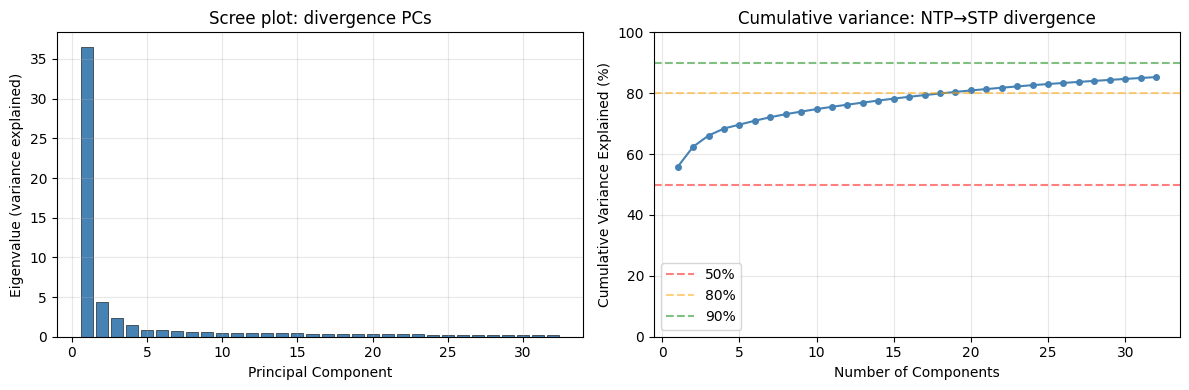

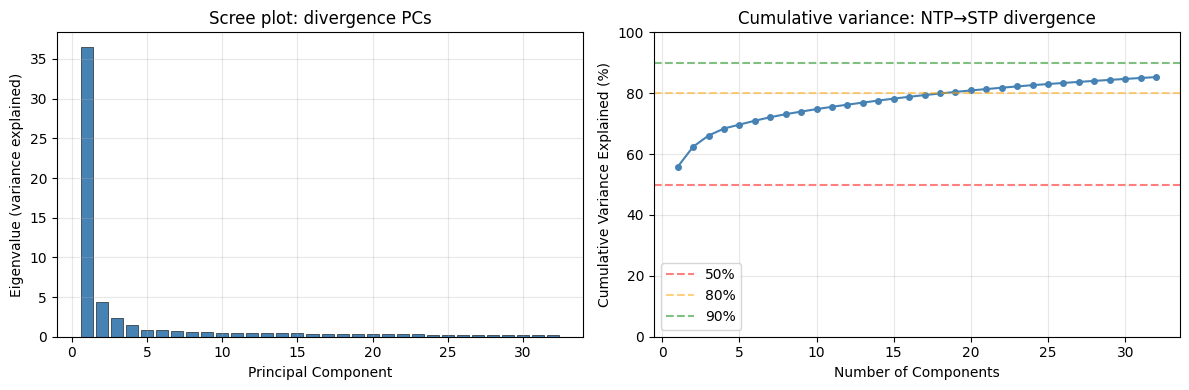

In [6]:
plot_scree(eigenvalues, cumvar, save_path="phase4b_scree.png")

## Step 5: Characterize Top Directions

For each of the top PCs, decode the tokens with the highest |projection|.

- **Positive projection**: STP moved this token's representation MORE in this direction
- **Negative projection**: STP moved it LESS (opposite direction)

Structural scaffold tokens (`<|begin_of_text|>`, `\n\n`, `<|eot_id|>`, etc.) are
filtered out — they appear at fixed positions in every sequence and flood every PC.

In [7]:
structural_ids = get_structural_token_ids(tokenizer)
print(f"Filtering {len(structural_ids)} structural token IDs")

char_results = characterize_directions(
    components, projections, token_ids, seq_indices,
    tokenizer, top_k_tokens=50, n_components=5,
    filter_ids=structural_ids,
)
print_pc_summary(char_results, n_components=5, n_show=20)

Filtering 5 structural token IDs

PC 1: Top tokens by absolute projection

  POSITIVE (STP > NTP in this direction):
    '['                   proj=+1.507  seq=376
    '*['                  proj=+1.459  seq=1689
    '(['                  proj=+1.458  seq=1576
    '*['                  proj=+1.457  seq=1348
    '((['                 proj=+1.454  seq=1253
    '*['                  proj=+1.451  seq=515
    ')){'                 proj=+1.445  seq=331
    ']).'                 proj=+1.444  seq=1369
    '((['                 proj=+1.442  seq=253
    '['                   proj=+1.439  seq=231
    '((['                 proj=+1.432  seq=208
    '['                   proj=+1.430  seq=1095
    '((['                 proj=+1.415  seq=551
    '((['                 proj=+1.414  seq=280
    '((['                 proj=+1.402  seq=1595
    '((['                 proj=+1.401  seq=1946
    '(['                  proj=+1.400  seq=937
    '((['                 proj=+1.399  seq=1555
    '((['                 pr

## Step 6: Token Type Distributions per PC

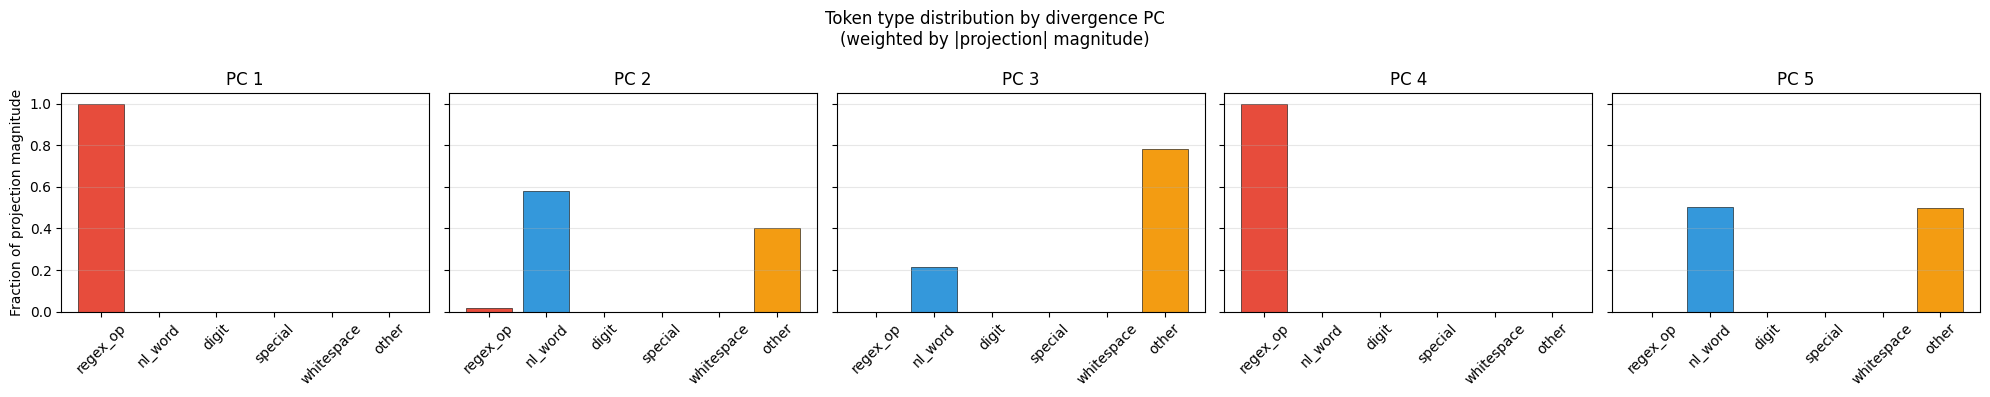

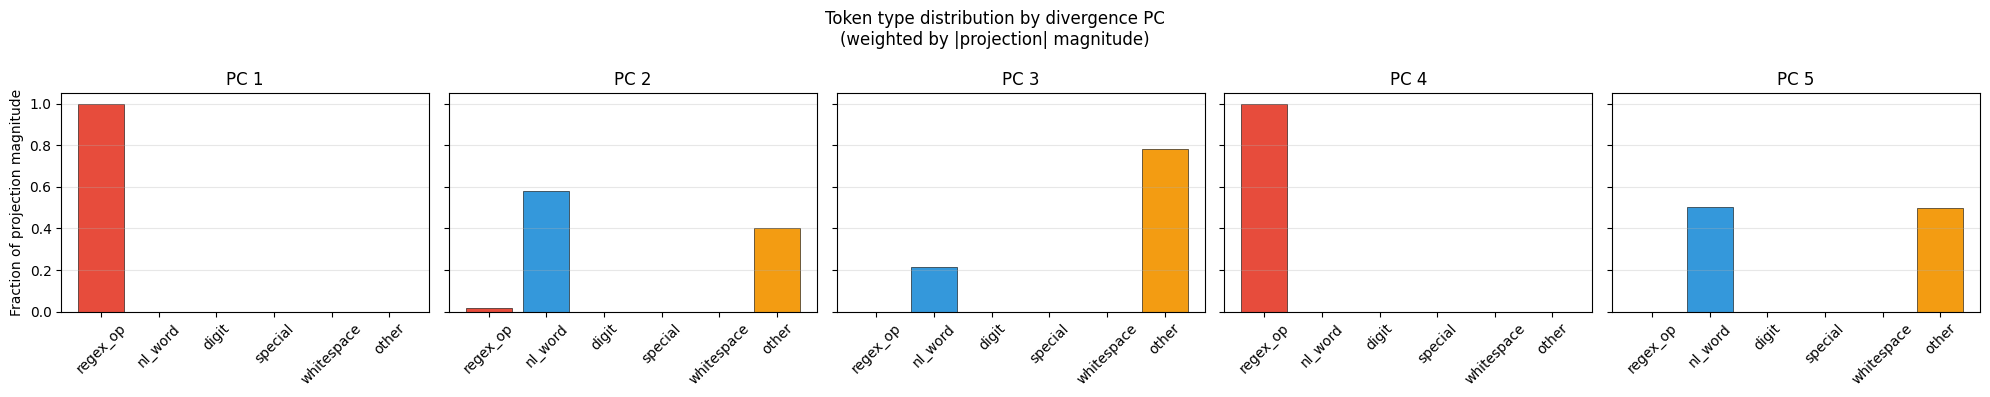

In [8]:
plot_token_types_per_pc(char_results, n_components=5,
                        save_path="phase4b_token_types.png")

## Step 7: PC1 vs PC2 Scatter

2D scatter of tokens (sampled) projected onto the top two divergence directions,
colored by token type. Structural tokens filtered.

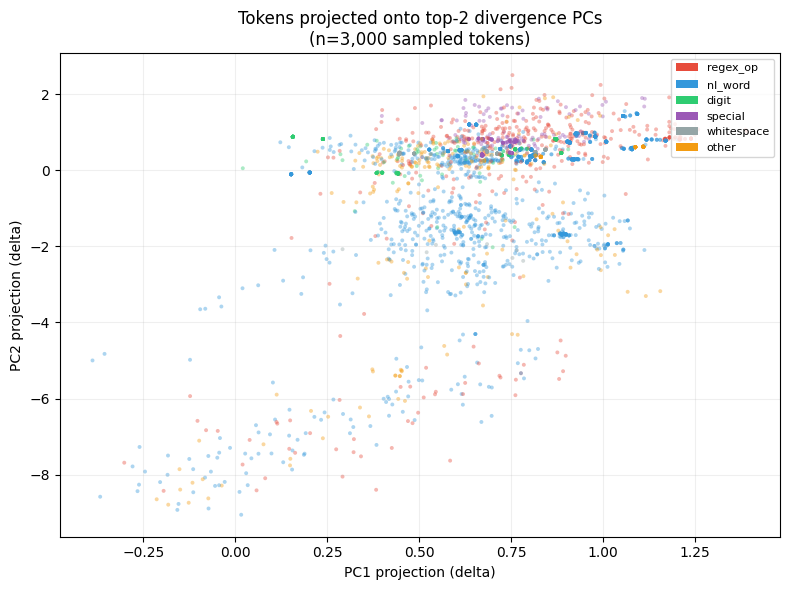

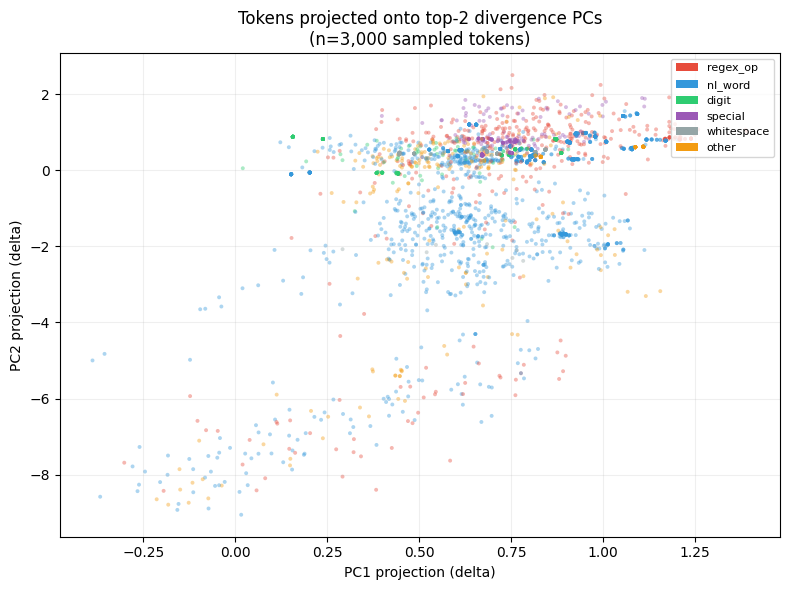

In [9]:
# Filter token_ids and projections for scatter plot too
keep_mask = np.array([int(t) not in structural_ids for t in token_ids])
plot_pc1_pc2_scatter(
    projections[keep_mask],
    token_ids[keep_mask],
    tokenizer,
    n_sample=3000,
    save_path="phase4b_scatter.png",
)

## Summary

Key numbers to report:
1. `delta_norm_ratio`: how much of activation energy was touched by LoRA
2. How many PCs to reach 50/80/90% of delta variance (structured vs diffuse)
3. Whether specific token types dominate each PC (semantic vs random change)

In [10]:
print(f"delta_norm_ratio = {delta_norm_ratio:.4f}")
print(f"Components for 50% delta var: {int((cumvar < 0.5).sum()) + 1}")
print(f"Components for 80% delta var: {int((cumvar < 0.8).sum()) + 1}")
print(f"Components for 90% delta var: {int((cumvar < 0.9).sum()) + 1}")
print(f"PC1 fraction of delta var: {cumvar[0]:.3f}")
print(f"PC1+PC2 fraction: {cumvar[1]:.3f}")

delta_norm_ratio = 0.3802
Components for 50% delta var: 1
Components for 80% delta var: 19
Components for 90% delta var: 33
PC1 fraction of delta var: 0.558
PC1+PC2 fraction: 0.624


summary: in this phase we took final activations for a set of seuqnces, for the differences between the models, and computed pca to find what the components consist of. We see that pc1 explain 55% oif the vairance, pretty good. The PC content mostly consists of regex stuff.